# Ejemplo aplicado: clasificación multiclase — Thyroid (UCI)

Misma plantilla que [03-clasificacion-multiple.ipynb](../03-clasificacion-multiple.ipynb), configurada para `thyroid.csv`.
Mantiene las **3 clases** del subconjunto UCI `allbp`: `negative`, `increased_binding_protein`, `decreased_binding_protein`.
Para detectar alteración de binding protein sin distinguir ↑/↓, usa el ejemplo binario en
[02-clasificacion-binaria-thyroid.ipynb](../02-clasificacion-binaria/02-clasificacion-binaria-thyroid.ipynb).

> Para un CSV nuevo, parte de la **plantilla genérica** correspondiente, no de este archivo.


In [1]:
# --- Imports ---
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def infer_feature_columns(df, target_col, drop_cols, feature_cols):
    """Columnas que entran como X. Si FEATURE_COLS es None, todas salvo target y DROP_COLS."""
    if feature_cols is not None:
        return list(feature_cols)
    exclude = {target_col, *drop_cols}
    return [c for c in df.columns if c not in exclude]


def infer_column_types(X, numeric_cols=None, categorical_cols=None):
    """Separa numéricas y categóricas para ColumnTransformer."""
    if numeric_cols is None:
        numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = X.select_dtypes(
            include=["object", "category", "bool", "string"]
        ).columns.tolist()
    return list(numeric_cols), list(categorical_cols)


def build_preprocess(numeric_cols, categorical_cols):
    """Preprocesador compartido: imputar → escalar / one-hot. Fit solo en train (Pipeline)."""
    transformers = []
    if numeric_cols:
        transformers.append(
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_cols,
            )
        )
    if categorical_cols:
        transformers.append(
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_cols,
            )
        )
    if not transformers:
        raise ValueError("No hay columnas numéricas ni categóricas para preprocesar.")
    return ColumnTransformer(transformers, remainder="drop")



def read_csv_checked(path, sep, required_cols=None):
    """Lee CSV y comprueba separador y columnas (evita KeyError si CSV_SEP ≠ PREVIEW_SEP)."""
    df = pd.read_csv(path, sep=sep)
    if df.shape[1] == 1:
        raise ValueError(
            f"Solo 1 columna con sep={sep!r}. CSV_SEP debe coincidir con PREVIEW_SEP del paso 1."
        )
    if required_cols:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(
                f"Faltan columnas {missing}. Revisa CSV_SEP (actual {sep!r}). "
                f"Columnas leídas: {list(df.columns)}"
            )
    return df


def prepare_multiclass_target(df, *, raw_label_col, target_col, class_names=None):
    """Codifica el target a enteros 0..K-1. class_names=None infiere K del CSV."""
    out = df.copy()
    if raw_label_col is not None:
        series = out[raw_label_col]
        if class_names is None:
            class_names = sorted(series.dropna().unique(), key=lambda x: str(x))
        label_to_id = {label: i for i, label in enumerate(class_names)}
        out[target_col] = series.map(label_to_id)
        if out[target_col].isna().any():
            bad = series[out[target_col].isna()].unique()
            raise ValueError(f"Etiquetas sin mapear en CLASS_NAMES: {bad!r}")
    else:
        out[target_col] = pd.to_numeric(out[target_col], errors="raise")
        values = sorted(out[target_col].dropna().unique())
        k = len(values)
        if class_names is None:
            class_names = [str(int(v)) if float(v).is_integer() else str(v) for v in values]
        elif len(class_names) != k:
            raise ValueError(
                f"CLASS_NAMES ({len(class_names)}) no coincide con {k} clases: {values}"
            )
        ints = [int(v) for v in values]
        if ints != list(range(k)):
            raise ValueError(
                f"TARGET_COL debe ser 0..{k - 1} sin huecos; encontrado: {ints}"
            )
    out[target_col] = out[target_col].astype(int)
    k = len(class_names)
    if k < 3:
        raise ValueError(
            f"Multiclase requiere >= 3 clases (K={k}). Usa plantilla binaria si K=2."
        )
    return out, list(class_names)


def split_train_val_test(X, y, test_size, val_size, random_state, stratify=False):
    """Divide en train, validación y test (dos llamadas a train_test_split).

    - test_size: fracción del total para test (hold-out final, paso 9).
    - val_size: fracción de train+val; el benchmark (paso 8) usa solo val.
    Con test_size=0.2 y val_size=0.25 → ~60 % train, ~20 % val, ~20 % test.
    """
    kw = dict(test_size=test_size, random_state=random_state)
    if stratify:
        kw["stratify"] = y
    X_tv, X_test, y_tv, y_test = train_test_split(X, y, **kw)
    kw2 = dict(test_size=val_size, random_state=random_state)
    if stratify:
        kw2["stratify"] = y_tv
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, **kw2)
    return X_train, X_val, X_test, y_train, y_val, y_test

def discretize_series(series, n_bins=5, max_classes=25):
    """Discretiza una serie para tablas target×feature (redondeo o bins por cuantiles)."""
    s = pd.Series(series)
    if s.nunique() <= max_classes:
        return np.round(s).astype(int).to_numpy(), "valores redondeados"
    edges = np.unique(np.quantile(s.dropna(), np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 2:
        edges = np.linspace(float(s.min()), float(s.max()), n_bins + 1)
    binned = np.digitize(s, edges[1:-1])
    return binned, f"{len(edges) - 1} intervalos (cuantiles)"




## 1. Explorar el CSV (antes de CONFIG)

Mismos parámetros que usarás en CONFIG.


In [2]:
# --- Ajusta solo estas dos líneas para TU csv ---
PREVIEW_PATH = "../data/thyroid.csv"
PREVIEW_SEP = ','

df_preview = pd.read_csv(PREVIEW_PATH, sep=PREVIEW_SEP)

print(f"Filas: {len(df_preview):,}  |  Columnas: {len(df_preview.columns)}")
print("\n--- Nombres de columnas ---")
for i, col in enumerate(df_preview.columns):
    print(f"  {i:2d}: {col!r}")

print("\n--- Tipos (dtypes) ---")
print(df_preview.dtypes)

print("\n--- Primeras filas ---")
display(df_preview.head())

print("\n--- Valores faltantes ---")
missing = df_preview.isna().sum()
if missing.any():
    display(missing[missing > 0].to_frame("nulos"))
else:
    print("No hay valores faltantes.")

_num = df_preview.select_dtypes(include=[np.number]).columns.tolist()
_cat = df_preview.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
print("\n--- Sugerencia de tipos ---")
print("Numéricas:", _num)
print("Categóricas:", _cat)

if "class_label" in df_preview.columns:
    print("\n--- Distribución del posible target (3 clases) ---")
    print(df_preview["class_label"].value_counts())

print(
    "\n>>> Siguiente: en CONFIG usa el mismo path/separador y define TARGET_COL "
    "(K=3; CLASS_NAMES explícitos o None para inferir)."
)


Filas: 2,800  |  Columnas: 30

--- Nombres de columnas ---
   0: 'age'
   1: 'sex'
   2: 'on_thyroxine'
   3: 'query_on_thyroxine'
   4: 'on_antithyroid_medication'
   5: 'sick'
   6: 'pregnant'
   7: 'thyroid_surgery'
   8: 'I131_treatment'
   9: 'query_hypothyroid'
  10: 'query_hyperthyroid'
  11: 'lithium'
  12: 'goitre'
  13: 'tumor'
  14: 'hypopituitary'
  15: 'psych'
  16: 'TSH_measured'
  17: 'TSH'
  18: 'T3_measured'
  19: 'T3'
  20: 'TT4_measured'
  21: 'TT4'
  22: 'T4U_measured'
  23: 'T4U'
  24: 'FTI_measured'
  25: 'FTI'
  26: 'TBG_measured'
  27: 'TBG'
  28: 'referral_source'
  29: 'class_label'

--- Tipos (dtypes) ---
age                          float64
sex                           object
on_thyroxine                  object
query_on_thyroxine            object
on_antithyroid_medication     object
sick                          object
pregnant                      object
thyroid_surgery               object
I131_treatment                object
query_hypothyroid          

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,class_label
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,negative
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.0,f,NaN,f,NaN,f,NaN,other,negative
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,NaN,other,negative
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.0,f,NaN,f,NaN,f,NaN,other,negative
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,NaN,SVI,negative



--- Valores faltantes ---


,nulos
age,1
sex,110
TSH,284
T3,585
TT4,184
T4U,297
FTI,295
TBG,2800



--- Sugerencia de tipos ---
Numéricas: ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
Categóricas: ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured', 'referral_source', 'class_label']

--- Distribución del posible target (3 clases) ---
class_label
negative                     2667
increased_binding_protein     124
decreased_binding_protein       9
Name: count, dtype: int64

>>> Siguiente: en CONFIG usa el mismo path/separador y define TARGET_COL (K=3; CLASS_NAMES explícitos o None para inferir).


## 2. CONFIG — adaptar a tu dataset

Copia los valores de la exploración. **Solo esta sección** cambia entre proyectos.


In [3]:
# ========== Paso 2: CONFIG — único bloque que cambia entre datasets ==========
DATA_PATH = '../data/thyroid.csv'
CSV_SEP = ','

# XGBoost y CatBoost exigen target numérico (0..K-1). Si el CSV trae texto, define RAW_LABEL_COL.
RAW_LABEL_COL = "class_label"  # None si TARGET_COL ya es entero en el CSV
TARGET_COL = "target"
CLASS_NAMES = ['negative', 'increased_binding_protein', 'decreased_binding_protein']
DROP_COLS = ['class_label']
FEATURE_COLS = None
NUMERIC_COLS = None
CATEGORICAL_COLS = None

TEST_SIZE = 0.2
VAL_SIZE = 0.25
RANDOM_STATE = 42
METRIC_PRINCIPAL = 'f1'

def build_models(n_classes):
    """Diccionario nombre → estimador. Comenta líneas para excluir modelos del benchmark."""
    from sklearn.ensemble import (
        GradientBoostingClassifier,
        HistGradientBoostingClassifier,
        RandomForestClassifier,
    )
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.tree import DecisionTreeClassifier
    from xgboost import XGBClassifier
    from catboost import CatBoostClassifier

    if n_classes < 3:
        raise ValueError(f"build_models: K={n_classes} < 3 (multiclase)")
    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "DecisionTree": DecisionTreeClassifier(
            criterion="gini",
            splitter="best",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features=None,
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            random_state=RANDOM_STATE,
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100,
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            min_weight_fraction_leaf=0.0,
            max_features="sqrt",
            max_leaf_nodes=None,
            min_impurity_decrease=0.0,
            bootstrap=True,
            oob_score=False,
            max_samples=None,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "XGBoost": XGBClassifier(
            random_state=RANDOM_STATE,
            verbosity=0,
            n_estimators=100,
            objective="multi:softmax",
            num_class=n_classes,
            n_jobs=-1,
        ),
        "CatBoost": CatBoostClassifier(
            random_state=RANDOM_STATE,
            verbose=False,
            iterations=100,
            allow_writing_files=False,
            loss_function="MultiClass",
        ),
    }
    return models






## 3. Carga de datos


In [4]:
# --- Paso 3: carga definitiva con los parámetros de CONFIG ---
_required = [RAW_LABEL_COL] if RAW_LABEL_COL is not None else [TARGET_COL]
df = read_csv_checked(DATA_PATH, CSV_SEP, required_cols=_required)

df, CLASS_NAMES = prepare_multiclass_target(
    df,
    raw_label_col=RAW_LABEL_COL,
    target_col=TARGET_COL,
    class_names=CLASS_NAMES,
)
N_CLASSES = len(CLASS_NAMES)
MODELS = build_models(N_CLASSES)

print("Shape:", df.shape)
print(f"Clases (K={N_CLASSES}):", CLASS_NAMES)
print("\nDistribución del target:")
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename(index=lambda i: CLASS_NAMES[i])
)
df.head()


Shape: (2800, 31)
Clases (K=3): ['negative', 'increased_binding_protein', 'decreased_binding_protein']

Distribución del target:
target
negative                     2667
increased_binding_protein     124
decreased_binding_protein       9
Name: count, dtype: int64


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,class_label,target
0,41.0,F,f,f,f,f,f,f,f,f,...,125.0,t,1.14,t,109.0,f,NaN,SVHC,negative,0
1,23.0,F,f,f,f,f,f,f,f,f,...,102.0,f,NaN,f,NaN,f,NaN,other,negative,0
2,46.0,M,f,f,f,f,f,f,f,f,...,109.0,t,0.91,t,120.0,f,NaN,other,negative,0
3,70.0,F,t,f,f,f,f,f,f,f,...,175.0,f,NaN,f,NaN,f,NaN,other,negative,0
4,70.0,F,f,f,f,f,f,f,f,f,...,61.0,t,0.87,t,70.0,f,NaN,SVI,negative,0


## 4. Calidad de datos


In [5]:
# --- Paso 4: balance de clases y faltantes ---
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename(index=lambda i: CLASS_NAMES[i])
)
print("\nFaltantes:")
print(df.isna().sum().pipe(lambda s: s[s > 0] if s.any() else "Sin faltantes"))




target
negative                     2667
increased_binding_protein     124
decreased_binding_protein       9
Name: count, dtype: int64

Faltantes:
age       1
sex     110
TSH     284
T3      585
TT4     184
T4U     297
FTI     295
TBG    2800
dtype: int64


## 5. Visualización rápida


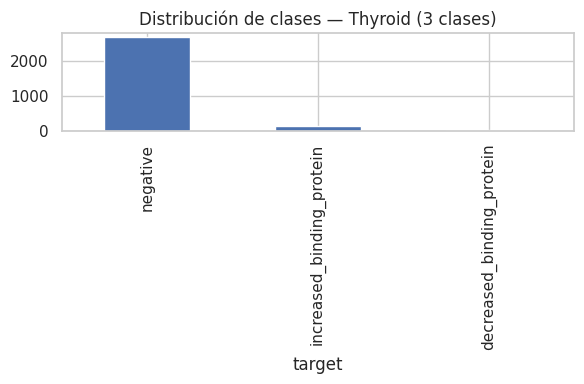

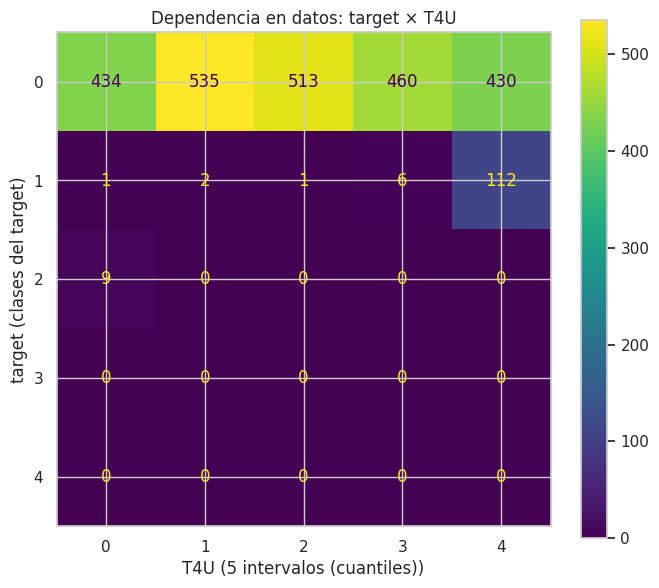

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
    .rename(index=lambda i: CLASS_NAMES[i])
    .plot(kind="bar", ax=ax)
)
ax.set_title("Distribución de clases — Thyroid (3 clases)")
ax.set_xlabel(TARGET_COL)
plt.tight_layout()
plt.show()

feature_cols_eda = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)

# Feature para matriz target×feature (sin heatmap de correlación)
num_cols = [
    c for c in feature_cols_eda
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]
top_feat = None
if num_cols and pd.api.types.is_numeric_dtype(df[TARGET_COL]):
    s = df[num_cols].corrwith(df[TARGET_COL]).abs().sort_values(ascending=False)
    if len(s.dropna()):
        top_feat = s.idxmax()

# --- Matriz de confusión target × feature (dependencias en datos crudos) ---
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

CM_BINS = 5
CM_MAX_CLASSES = 25

if top_feat is None:
    print("No hay features para la matriz target×feature.")
else:
    y = df[TARGET_COL]
    x = df[top_feat]
    mask = y.notna() & x.notna()
    y_clean, x_clean = y[mask], x[mask]

    if pd.api.types.is_numeric_dtype(y_clean) and y_clean.nunique() > CM_MAX_CLASSES:
        y_disc, y_note = discretize_series(y_clean, CM_BINS, CM_MAX_CLASSES)
    else:
        y_disc = pd.Categorical(y_clean).codes
        y_note = "clases del target"

    if pd.api.types.is_numeric_dtype(x_clean) and x_clean.nunique() > CM_MAX_CLASSES:
        x_disc, x_note = discretize_series(x_clean, CM_BINS, CM_MAX_CLASSES)
    else:
        x_disc = pd.Categorical(x_clean).codes
        x_note = "categorías de la feature"

    cm = confusion_matrix(y_disc, x_disc)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=True)
    ax.set_xlabel(f"{top_feat} ({x_note})")
    ax.set_ylabel(f"{TARGET_COL} ({y_note})")
    ax.set_title(f"Dependencia en datos: {TARGET_COL} × {top_feat}")
    plt.tight_layout()
    plt.show()


## 6. X / y y split (estratificado)


In [7]:
feature_cols = infer_feature_columns(df, TARGET_COL, DROP_COLS, FEATURE_COLS)
X = df[feature_cols]
y = df[TARGET_COL]
numeric_cols, categorical_cols = infer_column_types(X, NUMERIC_COLS, CATEGORICAL_COLS)

print("Numéricas:", len(numeric_cols), "| Categóricas:", len(categorical_cols))


X_train, X_val, X_test, y_train, y_val, y_test = split_train_val_test(
    X, y,
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=True,
)
print(
    f"Tamaños → train: {len(X_train):,} | val: {len(X_val):,} | test: {len(X_test):,}"
)



Numéricas: 7 | Categóricas: 22
Tamaños → train: 1,680 | val: 560 | test: 560


## 7. Preprocesado


In [8]:
preprocess = build_preprocess(numeric_cols, categorical_cols)


## 8. Comparar modelos

Métricas en **train** y **val**; brecha train−val para detectar **overfitting**.



In [ ]:
# --- Paso 8: métricas y benchmark de modelos ---

OVERFIT_GAP_WARN = 0.15  # brecha train-val en METRIC_PRINCIPAL por encima → posible overfitting

def classification_metrics(y_true, y_pred):
    """Accuracy, precision, recall y F1 (weighted en multiclase)."""
    from sklearn.metrics import (
        accuracy_score,
        f1_score,
        precision_score,
        recall_score,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def evaluate_models(models, preprocess, X_train, X_val, y_train, y_val):
    """Entrena en train; métricas en train y val para detectar overfitting."""
    rows = []
    metric = METRIC_PRINCIPAL
    for name, estimator in models.items():
        pipe = Pipeline([("preprocess", preprocess), ("model", estimator)])
        pipe.fit(X_train, y_train)
        m_train = classification_metrics(y_train, pipe.predict(X_train))
        m_val = classification_metrics(y_val, pipe.predict(X_val))
        row = {"modelo": name}
        for k, v in m_train.items():
            row[f"{k}_train"] = v
        for k, v in m_val.items():
            row[f"{k}_val"] = v
        row[f"gap_{metric}"] = m_train[metric] - m_val[metric]
        rows.append(row)
    return pd.DataFrame(rows).sort_values(f"{metric}_val", ascending=False)


results = evaluate_models(MODELS, preprocess, X_train, X_val, y_train, y_val)
display(results.round(4))

gap_col = f"gap_{METRIC_PRINCIPAL}"
sospechosos = results[results[gap_col] > OVERFIT_GAP_WARN]
if len(sospechosos):
    print(
        f"\nPosible overfitting (gap {METRIC_PRINCIPAL} train-val > {OVERFIT_GAP_WARN}):"
    )
    display(
        sospechosos[
            ["modelo", f"{METRIC_PRINCIPAL}_train", f"{METRIC_PRINCIPAL}_val", gap_col]
        ].round(4)
    )
else:
    print(
        f"\nSin gap {METRIC_PRINCIPAL} train-val > {OVERFIT_GAP_WARN} "
        "(no hay señal fuerte de overfitting en el benchmark)."
    )

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results.set_index("modelo")[
    [f"{METRIC_PRINCIPAL}_train", f"{METRIC_PRINCIPAL}_val"]
]
plot_df.plot(kind="barh", ax=ax)
ax.set_xlabel(METRIC_PRINCIPAL)
ax.set_title("Train vs validación — clasificación multiclase")
ax.legend(["train", "val"])
plt.tight_layout()
plt.show()




## 9. Detalle del mejor modelo


Mejor modelo (val): {best_name}

Métricas en test (tras reentrenar con train+val):


,accuracy,precision,recall,f1
0,0.9893,0.9856,0.9893,0.9874



                           precision    recall  f1-score   support

                 negative       0.99      1.00      0.99       533
increased_binding_protein       0.96      0.88      0.92        25
decreased_binding_protein       0.00      0.00      0.00         2

                 accuracy                           0.99       560
                macro avg       0.65      0.63      0.64       560
             weighted avg       0.99      0.99      0.99       560



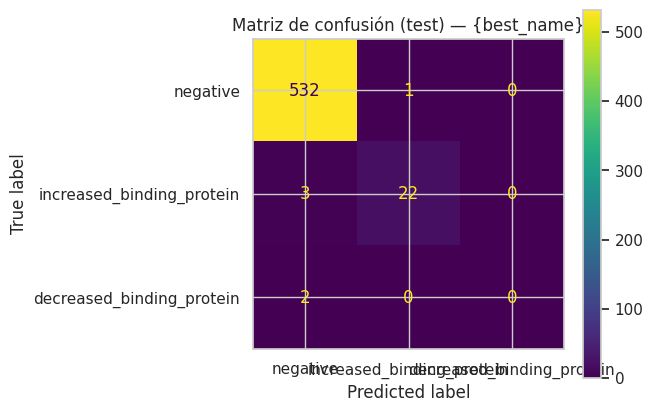

In [10]:
# --- Paso 9: reporte y matriz de confusión del mejor modelo ---
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best_name = results.iloc[0]["modelo"]
print(f"Mejor modelo (val): {{best_name}}\n")

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

best_pipe = Pipeline([("preprocess", preprocess), ("model", MODELS[best_name])])
best_pipe.fit(X_trainval, y_trainval)
y_pred = best_pipe.predict(X_test)

print("Métricas en test (tras reentrenar con train+val):")
display(pd.DataFrame([classification_metrics(y_test, y_pred)]).round(4))
print()

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=CLASS_NAMES
)
plt.title(f"Matriz de confusión (test) — {{best_name}}")
plt.tight_layout()
plt.show()




## Checklist: nuevo dataset (multiclase)

1. CSV en `data/` → explorar → CONFIG.
2. `CLASS_NAMES` explícitos o `None`; `N_CLASSES` y modelos tras paso 3.
3. `DROP_COLS` e ids; revisa faltantes y tipos.
4. Split **estratificado** por `y`.
5. Métrica principal habitual: **accuracy** o **F1 weighted**.
